In [5]:
import pandas as pd
df = pd.read_csv("heart_ash.csv")
print(df.head())
x = df.drop("target",axis = 1)
y = df["target"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1


In [6]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(x_train, y_train)
pred = dt.predict(x_test)
print(pred[:10])

[1 1 1]


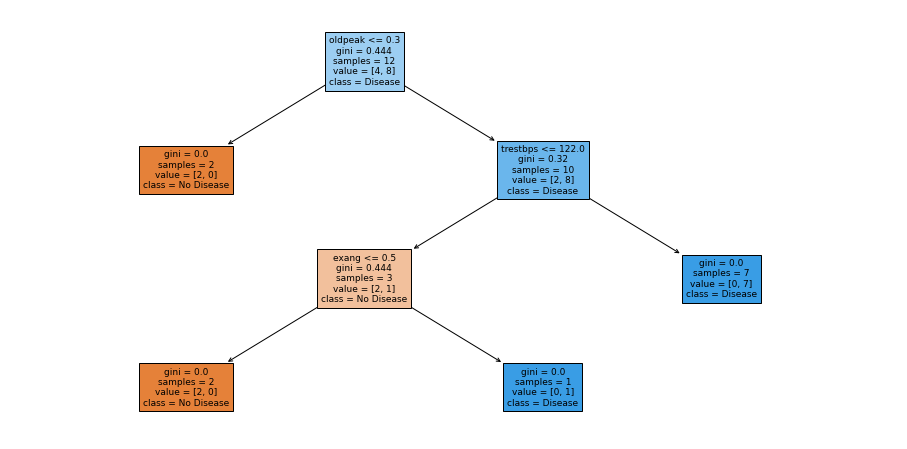

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize = (16, 8))
plot_tree(dt, feature_names = x.columns, class_names=["No Disease", "Disease"], filled = True, max_depth = 3, fontsize = 9)
plt.show()

In [11]:
for depth in[2, 3, 4, 5, None]:
    dt_d = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    dt_d.fit(x_train, y_train)
    train_acc = dt_d.score(x_train, y_train)
    test_acc = dt_d.score(x_test, y_test)
    print(depth, train_acc, test_acc)

2 0.9166666666666666 0.6666666666666666
3 1.0 0.6666666666666666
4 1.0 0.6666666666666666
5 1.0 0.6666666666666666
None 1.0 0.6666666666666666


In [12]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)


age         0.176912
chol        0.161287
oldpeak     0.154095
trestbps    0.148168
thalach     0.116003
exang       0.078267
sex         0.062149
cp          0.062040
ca          0.021853
fbs         0.019227
dtype: float64


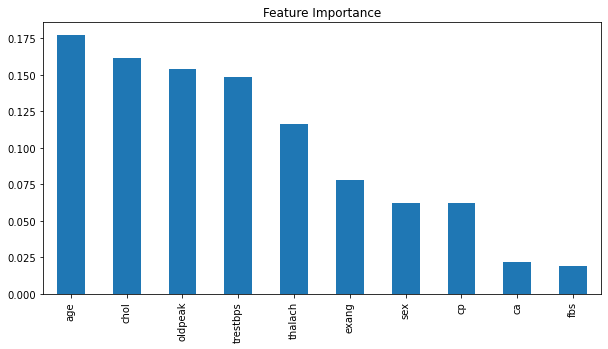

In [16]:
import numpy as np 
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index =x.columns).sort_values(ascending = False)
print(feat_imp)
feat_imp.plot(kind = "bar", figsize = (10,5))
plt.title("Feature Importance")
plt.show()

In [18]:
for n in [50, 100, 200]:
    for depth in[3, 5, None]:
        rf_t = RandomForestClassifier(n_estimators = n, max_depth = depth, random_state = 42)
        rf_t.fit(x_train, y_train)
        acc = rf_t.score(x_test, y_test)
        print(n, depth, acc)

50 3 0.3333333333333333
50 5 0.3333333333333333
50 None 0.3333333333333333
100 3 0.3333333333333333
100 5 0.3333333333333333
100 None 0.3333333333333333
200 3 0.3333333333333333
200 5 0.3333333333333333
200 None 0.3333333333333333


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression":LogisticRegression(max_iter = 1000),
    "KNN (K = 5)":KNeighborsClassifier(n_neighbors = 5),
    "Decision Tree":DecisionTreeClassifier(random_state = 42),
    "Random Forest":RandomForestClassifier(n_estimators = 100, random_state = 42),
    
}
results = []
for name, m in models.items():
    m.fit(x_train, y_train)
    p = m.predict(x_test)
    results.append([
        name,
        accuracy_score(y_test, p),
        precision_score(y_test, p),
        recall_score(y_test, p),
        f1_score(y_test, p),
    ])
    comparison_df = pd.DataFrame(results, columns =["Model","Accuracy","Precision","Recall","F1 score"])
    print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression  0.333333        0.5     0.5       0.5
                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression  0.333333        0.5     0.5       0.5
1          KNN (K = 5)  0.333333        0.5     0.5       0.5
                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression  0.333333   0.500000     0.5       0.5
1          KNN (K = 5)  0.333333   0.500000     0.5       0.5
2        Decision Tree  0.666667   0.666667     1.0       0.8
                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression  0.333333   0.500000     0.5       0.5
1          KNN (K = 5)  0.333333   0.500000     0.5       0.5
2        Decision Tree  0.666667   0.666667     1.0       0.8
3        Random Forest  0.333333   0.500000     0.5       0.5
